### Ejercicio 1: Modificación del modelo de red neuronal
**Objetivo:** Comprender la influencia del número de neuronas en la capa oculta.

- Modifica el modelo creando tres versiones distintas con capas ocultas de 32, 64 y 256 neuronas respectivamente.
- Entrena cada versión durante 5 épocas y compara la precisión obtenida en el conjunto de prueba.
- Explica brevemente cómo influye cambiar la cantidad de neuronas en la precisión del modelo.

### Ejercicio 2: Visualización y análisis de errores
**Objetivo:** Explorar los errores que comete el modelo.

- Tras entrenar el modelo original con 128 neuronas, identifica al menos 5 imágenes del conjunto de prueba que hayan sido clasificadas incorrectamente.
- Visualiza estas imágenes indicando cuál fue la predicción del modelo y cuál era el dígito real.
- Describe qué crees que pudo haber causado la confusión del modelo en estas imágenes específicas.

### Ejercicio 3: Evaluación del impacto del número de épocas
**Objetivo:** Analizar cómo afecta el número de épocas al rendimiento del modelo.

- Entrena el modelo original durante 3, 5, y 10 épocas.
- Registra la precisión obtenida en el conjunto de validación y en el conjunto de prueba para cada entrenamiento.
- Representa gráficamente los resultados (precisión vs. número de épocas) y analiza cómo varía el rendimiento a medida que incrementas el número de épocas.

Estos ejercicios están pensados para profundizar en la comprensión de conceptos clave como arquitectura de redes, análisis de resultados y la importancia del entrenamiento del modelo.

In [2]:
# Importaciones necesarias
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3440 - loss: 1.7415 - val_accuracy: 0.5341 - val_loss: 1.2127
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5379 - loss: 1.2139
Precisión en conjunto de prueba: 0.53
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


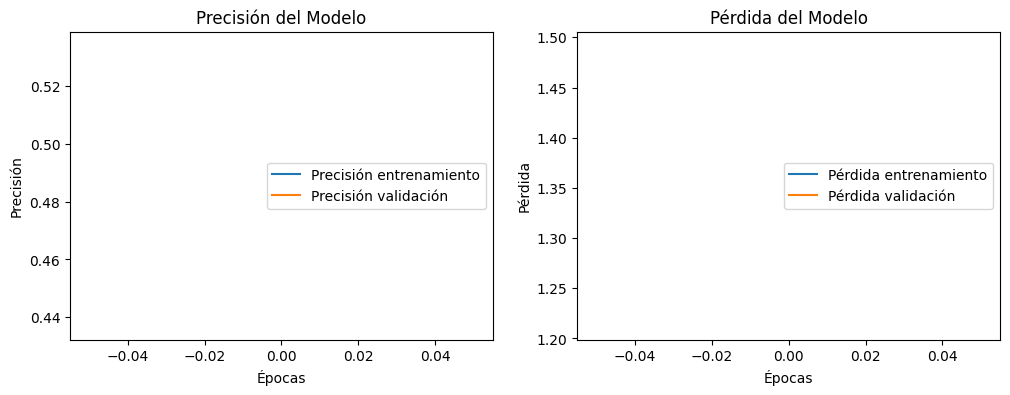

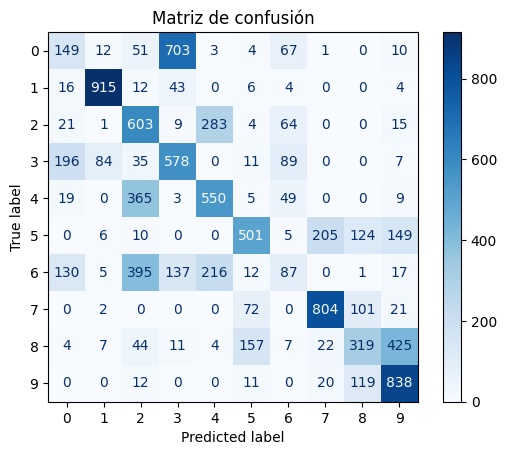

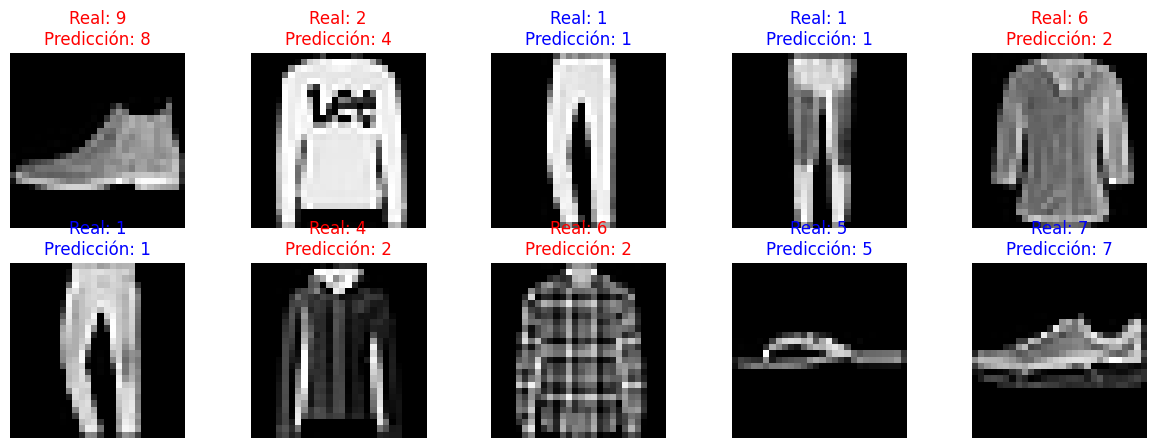

In [ ]:
# Carga del dataset Fashion-MNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalización de los datos
x_train = x_train / 255.0
x_test = x_test / 255.0

# Creación del modelo básico
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(2, activation='relu'),
    Dense(10, activation='softmax')
])

# Compilación del modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamiento del modelo
history = model.fit(x_train, y_train, epochs=1, validation_split=0.2)

# Evaluación del modelo
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Precisión en conjunto de prueba: {accuracy:.2f}')

# Predicciones del modelo
predicciones = model.predict(x_test)
predicciones_etiquetas = predicciones.argmax(axis=1)

# Visualización de resultados del entrenamiento
plt.figure(figsize=(12,4))

# Precisión
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Precisión entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión validación')
plt.title('Precisión del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Pérdida
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

# Matriz de confusión
cm = confusion_matrix(y_test, predicciones_etiquetas)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.show()

# Visualización de predicciones vs etiquetas reales
num_imagenes = 10
plt.figure(figsize=(15,5))
for i in range(num_imagenes):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')
    plt.title(f'Real: {y_test[i]}\nPredicción: {predicciones_etiquetas[i]}',
              color='blue' if predicciones_etiquetas[i] == y_test[i] else 'red')

plt.show()

### Gráfica de precisión (izquierda):
- **Precisión de entrenamiento** (línea azul):
  - Representa cómo mejora la clasificación del modelo sobre los datos con los que ha aprendido directamente.
  - Se espera que aumente constantemente con cada época, lo que indicaría que el modelo aprende progresivamente a reconocer patrones.

- **Precisión de validación** (línea naranja):
  - Representa cómo el modelo clasifica datos nuevos, que no ha visto durante el entrenamiento.
  - Idealmente, la precisión debería seguir aumentando de manera estable o estabilizarse. Sin embargo, cuando oscila, indica que el modelo podría empezar a sobreajustar (aprender patrones específicos de los datos de entrenamiento y no generalizar adecuadamente).

### Gráfica de pérdida (derecha):
- **Pérdida de entrenamiento** (línea azul):
  - Representa cómo disminuye el error cometido por el modelo sobre los datos del entrenamiento. Lo ideal es que disminuya constantemente.

- **Pérdida de validación** (línea naranja):
  - Representa cómo disminuye el error del modelo sobre datos nuevos (validación).
  - Cuando la pérdida de validación deja de bajar o empieza a subir ligeramente, puede indicar el inicio de sobreajuste. Es decir, el modelo comienza a memorizar en vez de generalizar.

### Matriz de confusión:

- Cada **fila** representa la **etiqueta real** (lo que debería haber predicho el modelo).
- Cada **columna** representa la **predicción del modelo** (lo que realmente predijo).
- El valor de cada celda indica cuántas veces se dio esa combinación.

La matriz te muestra dónde falla el modelo. No es solo el porcentaje total de aciertos, sino qué clases está confundiendo, lo que es muy útil para mejorar el entrenamiento o ajustar la arquitectura del modelo.

Valores grandes en la diagonal (de arriba a la izquierda hasta abajo a la derecha): indican predicciones correctas.
